Example of implementation of the Monte Carlo integration technique

In [1]:
import numpy as np
import scipy.stats
from scipy.optimize import curve_fit
from matplotlib import pyplot as plt

In [2]:
#initializing the gaussian distribution
mu = 0.
sigma = 2.
pdf = scipy.stats.norm(mu, sigma)

#defining the f function for Monte Carlo integration
def f(x):
    return np.sqrt(np.pi/2)*sigma*(x**3)

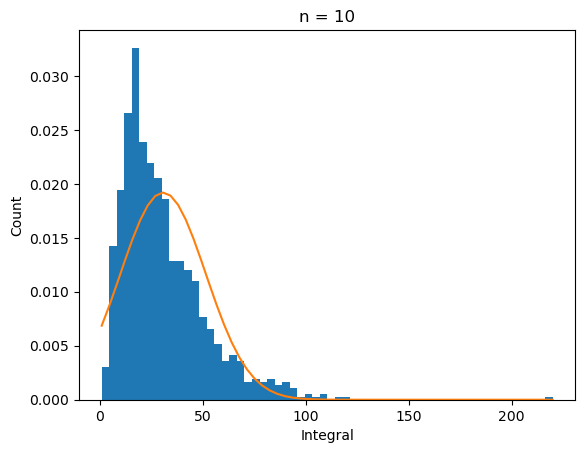

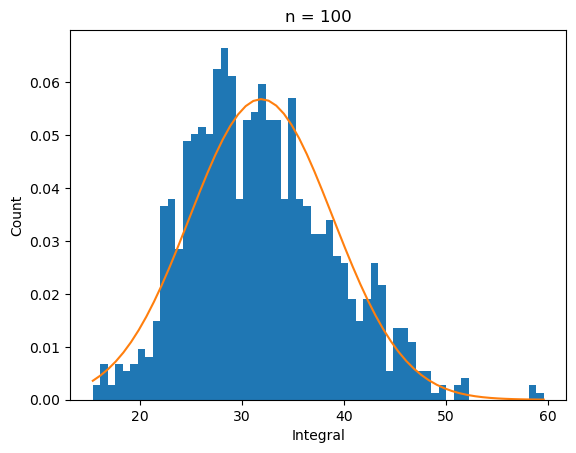

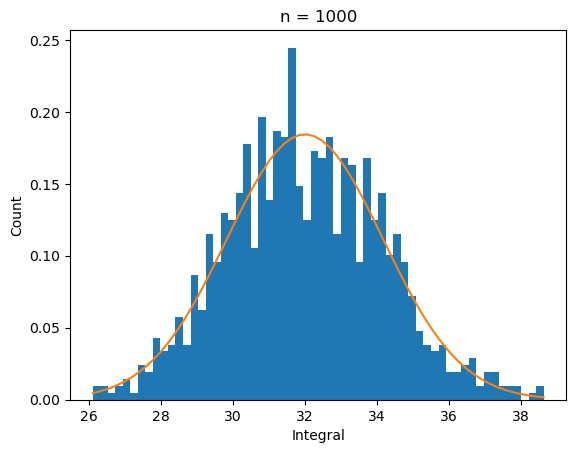

In [5]:
N = 1000 #number of iterations of MC integration
n_arr = [10, 100, 1000] #number of samplings for each computation of the integral
n_bins = 60

#the code samples N times the distribution of the value of the integral, and does so for various values of n
#(where n is the number of samplings of p(x) when computing the integral) then plots the histrograms of the data
#and tries to fit them with gaussians

for n in n_arr:
    
    MC_integral = []

    for i in range(N):
        
        f_xi = [f(np.abs(pdf.rvs())) for i in range(n)]
        MC_integral.append((1/n)*np.sum(f_xi))
    
    y, bins, patches = plt.hist(MC_integral, n_bins, density=True)
    x = np.linspace(bins[0], bins[-1], n_bins)
    mu_fit, sigma_fit = scipy.stats.norm.fit(MC_integral)
    fit_pdf = scipy.stats.norm.pdf(x, mu_fit, sigma_fit)
    #bin_width = bins[1]-bins[0]
    #scaled_pdf = fit_pdf * len(MC_integral) * bin_width
    plt.plot(x, fit_pdf)
    plt.xlabel('Integral')
    plt.ylabel('Count')
    plt.title('n = ' + str(n))
    plt.show()


We expect, according to the central limit theorem, the distribution of the values of the integral to approximate a gaussian as n gets large. With the width of the gaussian going down as 1/sqrt(n)